In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

 

In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/paultimothymooney
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/datasets/paultimothymooney/chest-x

In [3]:
import os

base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

for split in ['train', 'test', 'val']:
    print(f"\n{split.upper()} DATA")
    
    for category in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base_path, split, category)
        count = len(os.listdir(path))
        
        print(category, ":", count)


TRAIN DATA
NORMAL : 1341
PNEUMONIA : 3875

TEST DATA
NORMAL : 234
PNEUMONIA : 390

VAL DATA
NORMAL : 8
PNEUMONIA : 8


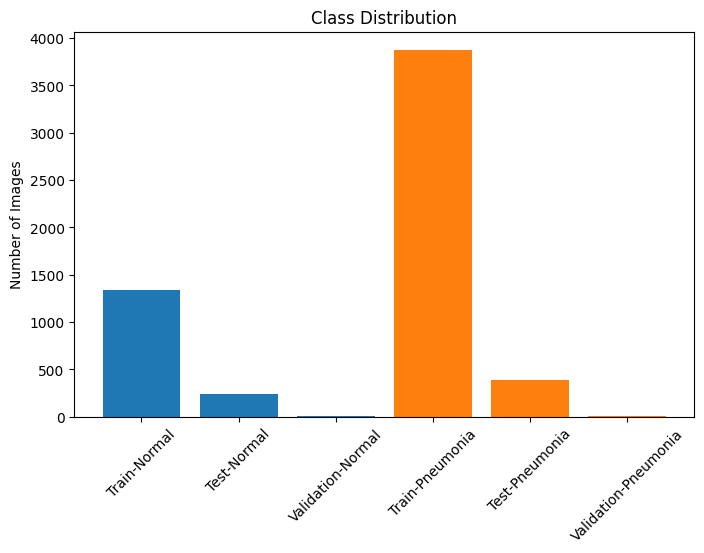

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Dataset': ['Train', 'Train', 'Test', 'Test', 'Validation', 'Validation'],
    'Class': ['Normal', 'Pneumonia', 'Normal', 'Pneumonia', 'Normal', 'Pneumonia'],
    'Count': [1341, 3875, 234, 390, 8, 8]
}

df = pd.DataFrame(data)

plt.figure(figsize=(8,5))
for cls in df['Class'].unique():
    subset = df[df['Class'] == cls]
    plt.bar(
        [f"{d}-{c}" for d, c in zip(subset['Dataset'], subset['Class'])],
        subset['Count']
    )

plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

The class distribution graph shows that the dataset is imbalanced.
The number of pneumonia images is significantly higher than normal images in the training and testing datasets.
This class imbalance may affect model performance and should be considered during model training.

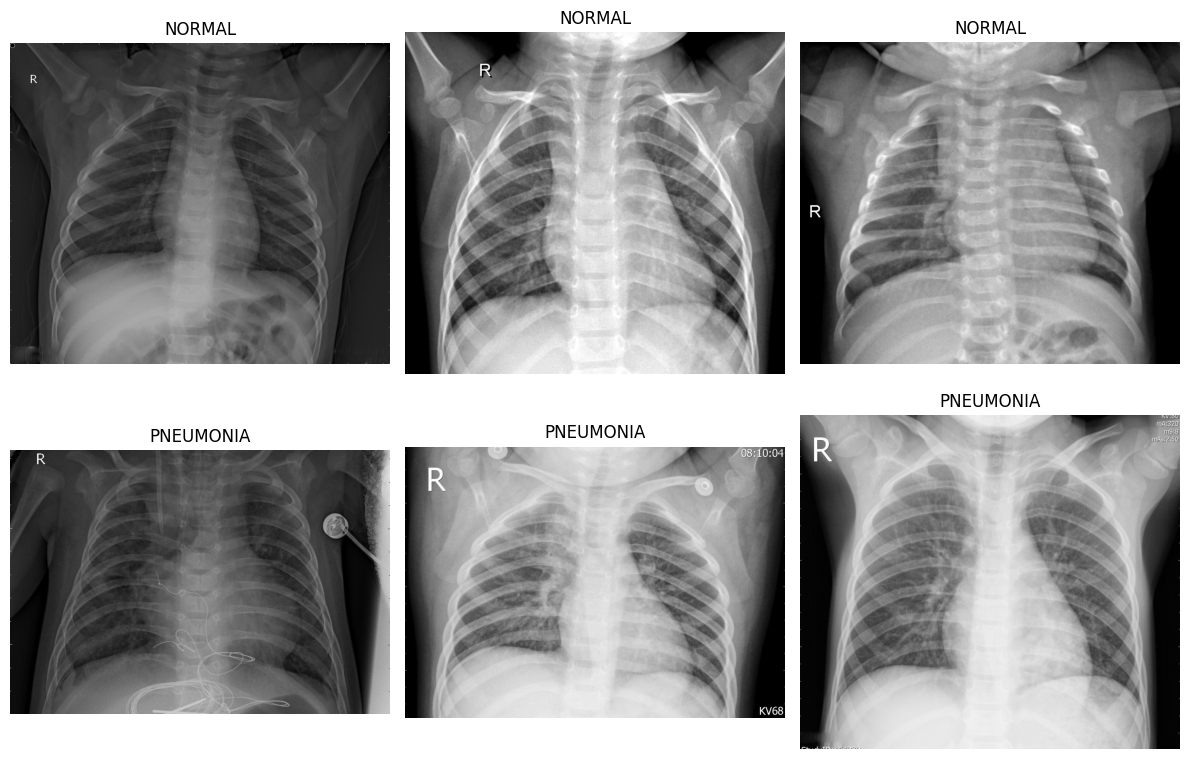

In [5]:
import os
import matplotlib.pyplot as plt
from PIL import Image

base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

normal_path = os.path.join(base_path, "train", "NORMAL")
pneumonia_path = os.path.join(base_path, "train", "PNEUMONIA")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, img_name in enumerate(os.listdir(normal_path)[:3]):
    img = Image.open(os.path.join(normal_path, img_name))
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title("NORMAL")
    axes[0, i].axis('off')

for i, img_name in enumerate(os.listdir(pneumonia_path)[:3]):
    img = Image.open(os.path.join(pneumonia_path, img_name))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### Sample Image Analysis

The sample chest X-ray images were visualized for both Normal and Pneumonia classes.

Observations:
- Normal chest X-rays generally show clear lung regions.
- Pneumonia chest X-rays show increased opacity and cloudy regions in some lung areas.
- Visual differences between classes indicate that image classification techniques can be used for pneumonia detection.

In [6]:
import os
from PIL import Image
import pandas as pd

base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

widths = []
heights = []

for category in ['NORMAL', 'PNEUMONIA']:
    
    folder = os.path.join(base_path, 'train', category)
    
    for img_name in os.listdir(folder)[:200]:
        
        img = Image.open(os.path.join(folder, img_name))
        w, h = img.size
        
        widths.append(w)
        heights.append(h)

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height :", min(heights))
print("Maximum Height :", max(heights))

Minimum Width : 428
Maximum Width : 2633
Minimum Height : 172
Maximum Height : 2578


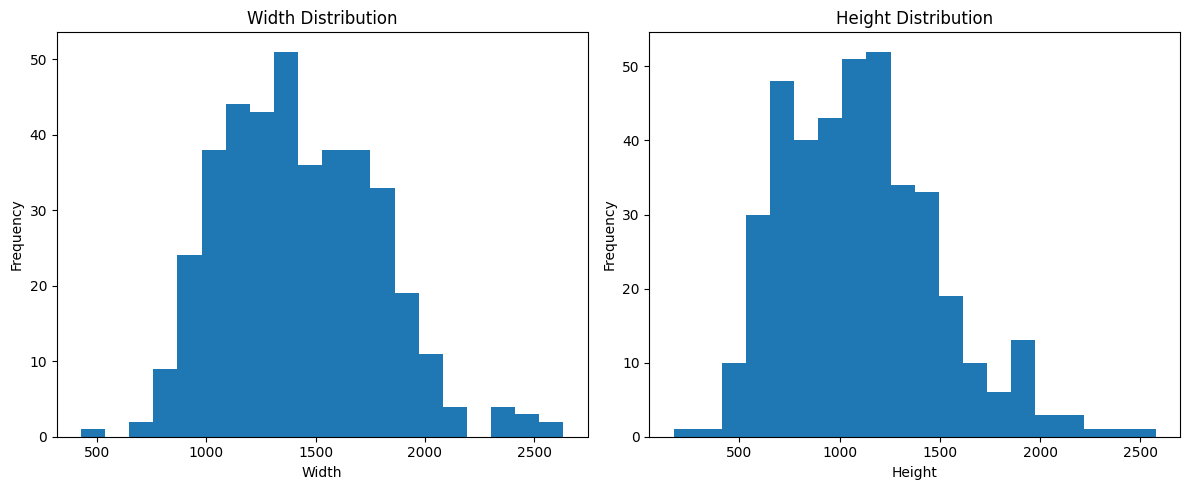

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Image Dimension Distribution

The width and height distribution graphs show that the dataset contains images of different sizes.

Observations:
- Most image widths lie between 1000 and 1800 pixels.
- Most image heights lie between 700 and 1500 pixels.
- A few images have significantly larger dimensions.
- Image resizing will be necessary before model training to maintain consistency.

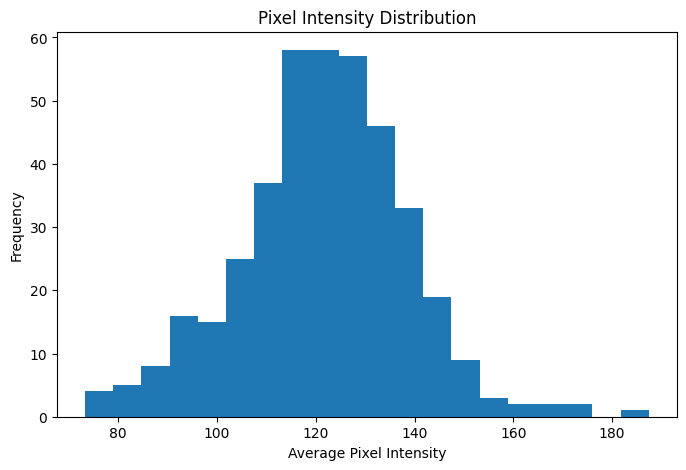

In [8]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

brightness = []

base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

for category in ['NORMAL', 'PNEUMONIA']:

    folder = os.path.join(base_path, 'train', category)

    for img_name in os.listdir(folder)[:200]:

        img = cv2.imread(os.path.join(folder, img_name), 0)

        brightness.append(np.mean(img))

plt.figure(figsize=(8,5))
plt.hist(brightness, bins=20)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Average Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

### Pixel Intensity Analysis

The pixel intensity distribution is approximately bell-shaped and centered around 110–130.

Observations:
- Most images have moderate brightness levels.
- Very few images are extremely dark or extremely bright.
- The dataset appears to have relatively consistent image exposure.
- Pixel normalization can further improve model performance during training.

# Conclusion

This exploratory data analysis was performed on the Chest X-Ray Pneumonia dataset.

Key Findings:

1. The dataset contains two classes: NORMAL and PNEUMONIA.
2. The training dataset is imbalanced, with pneumonia images significantly outnumbering normal images.
3. Visual inspection shows noticeable differences between normal and pneumonia chest X-rays.
4. Image dimensions vary considerably across the dataset.
5. Most images fall within common width and height ranges, but some outliers exist.
6. Pixel intensity values are relatively consistent across images.
7. Image preprocessing techniques such as resizing and normalization will be required before model training.

The dataset is suitable for deep learning-based image classification tasks such as pneumonia detection using CNN architectures.